<h1>Verificación de hipótesis: estimación mediante los puntos</h1>

<h2>Estimación física directa del momento angular orbital</h2>

<p><strong>Hipótesis de trabajo.</strong> Si las restricciones geométricas y dinámicas se aplican directamente sobre las observaciones, es posible estimar el momento angular específico <em>L</em><sub>z</sub> sin ajustar primero todos los elementos orbitales. Esto puede evitar que la incertidumbre de parámetros auxiliares se propague innecesariamente al parámetro físico de interés.</p>

<p><strong>Objetivo.</strong> Evaluar esta hipótesis con órbitas keplerianas sintéticas y comparar la estimación directa con un ajuste orbital completo realizado mediante <code>orbitize 3.4.0</code>.</p>

> **Alcance:** pruebas controladas, una realización de ruido por barrido, cobertura de una órbita completa y unidades geométricas $G=M=1$. Los resultados verifican consistencia numérica; no demuestran todavía superioridad sobre datos reales.

# 0. Inicialización

## 0.0. Librerías

In [1]:
import json
from html.parser import HTMLParser
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from orbitize import kepler
from scipy.stats import gaussian_kde

pd.options.display.float_format = "{:,.6g}".format
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.6),
        "axes.grid": True,
        "grid.alpha": 0.22,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## 0.1. Configuración reproducible

In [2]:
SEED = 6
NUMBER_OF_POINTS = 20
ASTROMETRIC_ERROR_MAS = 0.20
PARALLAX_MAS = 1.0
MASS_SOLAR = 1.0
MONTE_CARLO_SAMPLES = 5_000
DAYS_PER_ORBIT_1_AU = 365.25

# Referencias suministradas por el usuario. Solo se dibujan cuando el valor
# correspondiente cae dentro del intervalo continuo de un barrido.
ORBIT_REFERENCES = {
    "S2": {"a": 2.4e4, "e": 0.885, "color": "tab:purple"},
    "S301": {"a": 1.6e4, "e": 0.982, "color": "tab:orange"},
}


def find_project_root(start=None):
    '''Encuentra la raíz del proyecto a partir del directorio actual.'''
    path = Path(start or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("No se encontró pyproject.toml en los directorios padre.")


PROJECT_ROOT = find_project_root()

pd.DataFrame(
    {
        "parámetro": [
            "semilla",
            "observaciones",
            "error astrométrico [mas]",
            "paralaje [mas]",
            "masa [M_sun]",
            "muestras Monte Carlo",
            "orbitize",
        ],
        "valor": [
            SEED,
            NUMBER_OF_POINTS,
            ASTROMETRIC_ERROR_MAS,
            PARALLAX_MAS,
            MASS_SOLAR,
            MONTE_CARLO_SAMPLES,
            version("orbitize"),
        ],
    }
)

,parámetro,valor
0,semilla,6
1,observaciones,20
2,error astrométrico [mas],0.2
3,paralaje [mas],1
4,masa [M_sun],1
5,muestras Monte Carlo,5000
6,orbitize,3.4.0


## 0.2. Funciones

### 0.2.1. Ajuste cónico en dos dimensiones

In [3]:
def conic_coefficients(xs, ys):
    '''Ajusta 1/r = A + B cos(theta) + C sin(theta).'''
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    scale = float(np.median(np.hypot(xs, ys)))
    xs, ys = xs / scale, ys / scale
    radii = np.hypot(xs, ys)
    design = np.stack([radii**2, xs * radii, ys * radii], axis=-1)
    normal_matrix = np.einsum("...ij,...ik->...jk", design, design)
    normal_vector = np.einsum("...ij,...i->...j", design, radii)
    coefficients = np.linalg.solve(normal_matrix, normal_vector[..., None])[..., 0]
    return coefficients / scale


def conic_elements(xs, ys):
    '''Obtiene (p, e, omega) desde los coeficientes cónicos.'''
    A, B, C = np.moveaxis(conic_coefficients(xs, ys), -1, 0)
    return 1 / A, np.hypot(B, C) / A, np.arctan2(C, B)


def estimate_Lz_conic(xs, ys):
    '''Calcula Lz = sqrt(p) para G = M = 1 y una órbita vista de frente.'''
    A = conic_coefficients(xs, ys)[..., 0]
    return np.sqrt(1 / np.where(A > 0, A, np.nan))


def get_posterior_Lz_conic(
    xs, ys, sigma_x, sigma_y, number_of_samples=MONTE_CARLO_SAMPLES, rng=None
):
    '''Propaga errores gaussianos de posición hacia muestras de Lz.'''
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    if not (xs.ndim == ys.ndim == 1 and len(xs) == len(ys)):
        raise ValueError("xs e ys deben ser arreglos unidimensionales de igual longitud.")
    if len(xs) < 3:
        raise ValueError("El ajuste cónico necesita al menos tres observaciones.")
    if sigma_x <= 0 or sigma_y <= 0:
        raise ValueError("Las desviaciones estándar deben ser positivas.")

    rng = np.random.default_rng() if rng is None else rng
    samples_x = rng.normal(xs, sigma_x, size=(number_of_samples, len(xs)))
    samples_y = rng.normal(ys, sigma_y, size=(number_of_samples, len(ys)))
    Lz_samples = estimate_Lz_conic(samples_x, samples_y)
    Lz_samples = Lz_samples[np.isfinite(Lz_samples)]
    if len(Lz_samples) < number_of_samples // 2:
        raise RuntimeError("Demasiadas realizaciones inválidas: el ajuste no es estable.")
    return Lz_samples

### 0.2.2. Generación orbital y ajuste cónico en tres dimensiones

In [4]:
def solve_kepler_equation(mean_anomaly, eccentricity, tolerance=1e-13, iterations=60):
    '''Resuelve E - e sin(E) = M mediante Newton-Raphson.'''
    eccentric_anomaly = mean_anomaly + eccentricity * np.sin(mean_anomaly)
    for _ in range(iterations):
        step = (
            eccentric_anomaly
            - eccentricity * np.sin(eccentric_anomaly)
            - mean_anomaly
        ) / (1 - eccentricity * np.cos(eccentric_anomaly))
        eccentric_anomaly = eccentric_anomaly - step
        if np.max(np.abs(step)) < tolerance:
            break
    return eccentric_anomaly


def kepler_orbit_3d(epochs, sma, ecc, inc, aop, pan, tau, mass=1.0):
    '''Genera posiciones (norte, este, profundidad) en AU.'''
    epochs = np.asarray(epochs, dtype=float)
    period = DAYS_PER_ORBIT_1_AU * np.sqrt(sma**3 / mass)
    mean_anomaly = 2 * np.pi * (epochs / period - tau)
    eccentric_anomaly = solve_kepler_equation(mean_anomaly, ecc)

    plane_x = sma * (np.cos(eccentric_anomaly) - ecc)
    plane_y = sma * np.sqrt(1 - ecc**2) * np.sin(eccentric_anomaly)
    cos_aop, sin_aop = np.cos(aop), np.sin(aop)
    cos_inc, sin_inc = np.cos(inc), np.sin(inc)
    cos_pan, sin_pan = np.cos(pan), np.sin(pan)

    rotated_x = plane_x * cos_aop - plane_y * sin_aop
    rotated_y = plane_x * sin_aop + plane_y * cos_aop
    north = rotated_x * cos_pan - rotated_y * cos_inc * sin_pan
    east = rotated_x * sin_pan + rotated_y * cos_inc * cos_pan
    depth = rotated_y * sin_inc
    return north, east, depth


def orbital_plane_basis(xs, ys, zs):
    '''Obtiene la normal y una base ortonormal del plano orbital.'''
    positions = np.stack([xs, ys, zs], axis=-1)
    scatter_matrix = np.einsum("...ij,...ik->...jk", positions, positions)
    normals = np.linalg.eigh(scatter_matrix)[1][..., 0]
    areal = np.cross(positions[..., :-1, :], positions[..., 1:, :]).sum(axis=-2)
    signs = np.sign(np.einsum("...i,...i->...", areal, normals))
    normals = normals * np.where(signs == 0, 1.0, signs)[..., None]

    seeds = np.zeros_like(normals)
    np.put_along_axis(
        seeds, np.argmin(np.abs(normals), axis=-1)[..., None], 1.0, axis=-1
    )
    first = np.cross(normals, seeds)
    first = first / np.linalg.norm(first, axis=-1, keepdims=True)
    second = np.cross(normals, first)
    return normals, first, second


def conic_elements_3d(xs, ys, zs):
    '''Obtiene (p, n_z) después de proyectar los puntos al plano orbital.'''
    positions = np.stack([xs, ys, zs], axis=-1)
    normals, first, second = orbital_plane_basis(xs, ys, zs)
    plane_x = np.einsum("...ij,...j->...i", positions, first)
    plane_y = np.einsum("...ij,...j->...i", positions, second)
    A = conic_coefficients(plane_x, plane_y)[..., 0]
    return 1 / np.where(A > 0, A, np.nan), normals[..., 2]


def estimate_Lz_conic_3d(xs, ys, zs):
    '''Calcula Lz = sqrt(p) n_z para G = M = 1.'''
    p, n_z = conic_elements_3d(xs, ys, zs)
    return np.sqrt(p) * n_z


def get_joint_samples_3d(
    xs,
    ys,
    zs,
    sigma_x,
    sigma_y,
    sigma_z,
    number_of_samples=MONTE_CARLO_SAMPLES,
    rng=None,
):
    '''Propaga cada realización observacional hacia muestras conjuntas (p, n_z).'''
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    zs = np.asarray(zs, dtype=float)
    if not (xs.ndim == ys.ndim == zs.ndim == 1 and len(xs) == len(ys) == len(zs)):
        raise ValueError("xs, ys y zs deben ser arreglos unidimensionales de igual longitud.")
    if len(xs) < 3:
        raise ValueError("El ajuste cónico necesita al menos tres observaciones.")
    if min(sigma_x, sigma_y, sigma_z) <= 0:
        raise ValueError("Las desviaciones estándar deben ser positivas.")

    rng = np.random.default_rng() if rng is None else rng
    samples_x = rng.normal(xs, sigma_x, size=(number_of_samples, len(xs)))
    samples_y = rng.normal(ys, sigma_y, size=(number_of_samples, len(ys)))
    samples_z = rng.normal(zs, sigma_z, size=(number_of_samples, len(zs)))
    p_samples, nz_samples = conic_elements_3d(samples_x, samples_y, samples_z)
    valid = np.isfinite(p_samples) & np.isfinite(nz_samples)
    if valid.sum() < number_of_samples // 2:
        raise RuntimeError("Demasiadas realizaciones inválidas: el ajuste no es estable.")
    return p_samples[valid], nz_samples[valid]

### 0.2.3. Recuperación de los barridos calculados

In [5]:
class _PandasTableParser(HTMLParser):
    """Extrae una tabla HTML producida por pandas sin dependencias adicionales."""

    def __init__(self):
        super().__init__()
        self.rows = []
        self.current_row = None
        self.current_cell = None

    def handle_starttag(self, tag, attrs):
        if tag == "tr":
            self.current_row = []
        elif tag in {"th", "td"} and self.current_row is not None:
            self.current_cell = []

    def handle_data(self, data):
        if self.current_cell is not None:
            self.current_cell.append(data)

    def handle_endtag(self, tag):
        if tag in {"th", "td"} and self.current_cell is not None:
            self.current_row.append("".join(self.current_cell).strip())
            self.current_cell = None
        elif tag == "tr" and self.current_row:
            self.rows.append(self.current_row)
            self.current_row = None


def load_source_result(cell_id):
    """Carga el DataFrame mostrado por una celda ejecutada del notebook fuente."""
    source_path = (
        PROJECT_ROOT
        / "notebooks"
        / "011-determinacion_de_parametros_mediante_fisica.ipynb"
    )
    source_notebook = json.loads(source_path.read_text())
    source_cell = next(
        cell for cell in source_notebook["cells"] if cell.get("id") == cell_id
    )
    html = next(
        "".join(output["data"]["text/html"])
        for output in reversed(source_cell.get("outputs", []))
        if "text/html" in output.get("data", {})
    )
    parser = _PandasTableParser()
    parser.feed(html)
    columns = parser.rows[0][1:]
    rows = [row[1:] for row in parser.rows[1:] if len(row) == len(columns) + 1]
    frame = pd.DataFrame(rows, columns=columns)
    for column in frame.columns:
        numeric = pd.to_numeric(frame[column], errors="coerce")
        if numeric.notna().all():
            frame[column] = numeric
    return frame



def normalize_Lz_errors(frame, true_Lz, columns):
    """Convierte columnas de error absoluto a |Delta Lz| / |Lz_real|."""
    result = frame.copy()
    denominator = np.asarray(true_Lz, dtype=float)
    if np.any(~np.isfinite(denominator)) or np.any(np.abs(denominator) <= 0):
        raise ValueError("Lz_real debe ser finito y distinto de cero.")
    for column in columns:
        result[column] = result[column].to_numpy(dtype=float) / np.abs(denominator)
    return result


def add_in_range_orbit_markers(ax, values, parameter):
    """Añade referencias solo cuando caen dentro del rango mostrado."""
    lower, upper = np.nanmin(values), np.nanmax(values)
    for name, reference in ORBIT_REFERENCES.items():
        value = reference[parameter]
        if lower <= value <= upper:
            ax.axvline(
                value,
                color=reference["color"],
                linestyle="-.",
                linewidth=1.2,
                label=rf"{name}: ${parameter}={value:g}$",
            )
    ax.legend()



def relative_error_percentile_interval(Lz_samples, Lz_real):
    """Transforma el intervalo percentil de Lz a una envolvente de error relativo."""
    Lz_samples = np.asarray(Lz_samples, dtype=float)
    lower_Lz, median_Lz, upper_Lz = np.quantile(
        Lz_samples, [0.025, 0.50, 0.975]
    )
    denominator = np.abs(Lz_real)
    center = np.abs(median_Lz - Lz_real) / denominator
    endpoint_errors = np.abs(
        np.array([lower_Lz, upper_Lz]) - Lz_real
    ) / denominator
    lower = 0.0 if lower_Lz <= Lz_real <= upper_Lz else endpoint_errors.min()
    upper = endpoint_errors.max()
    tolerance = 64 * np.finfo(float).eps * max(1.0, upper)
    if not lower - tolerance <= center <= upper + tolerance:
        raise AssertionError("La mediana debe quedar dentro del intervalo transformado.")
    return center, lower, upper


def shade_percentile_interval(ax, x, lower, upper, color, label=None):
    """Dibuja un intervalo percentil central del 95% sin alterar límites log."""
    y_limits = ax.get_ylim()
    ax.fill_between(
        x,
        lower,
        upper,
        color=color,
        alpha=0.18,
        linewidth=0,
        label=label or "Intervalo percentil del 95%",
        zorder=0,
    )
    # Si Lz_real cae dentro del intervalo, el error mínimo es cero. En escala
    # logarítmica se recorta visualmente al borde inferior ya establecido.
    ax.set_ylim(y_limits)


def plot_Lz_errors(ax, frame, x, series, *, xlog=False, title=None):
    """Grafica errores de estimadores de Lz con una convención visual común."""
    styles = {
        "orbitize": ("s--", "tab:blue", "orbitize 3.4.0"),
        "Conic fit": ("o-", "black", r"Ajuste cónico $1/\sqrt{A}$"),
        "Conic posterior": ("v:", "tab:green", r"Mediana de $P(L_z)$"),
        "Conic 3D fit": ("o-", "black", r"Ajuste cónico 3D $\sqrt{p}\,n_z$"),
        "Conic 3D posterior": ("v:", "tab:green", r"Mediana de $P(L_z)$"),
        "Position and time posterior": (
            "v:",
            "tab:green",
            r"Mediana de $P(L_z\mid r,\Delta t)$",
        ),
        "Geometric": ("o-", "black", r"Mediana de $\sqrt{p}\,n_z$"),
        "With time": (
            "v:",
            "tab:orange",
            r"Mediana de $\sqrt{a(1-e^2)}\,n_z$",
        ),
        "Schwarzschild (pygro)": (
            "o-",
            "black",
            "Ajuste relativista (pygro)",
        ),
        "Kepler (orbitize)": (
            "s--",
            "tab:blue",
            "Ajuste kepleriano (orbitize)",
        ),
        "sesgo predicho": (
            ":",
            "tab:red",
            "Sesgo kepleriano predicho",
        ),
    }
    for column in series:
        marker, color, label = styles[column]
        ax.plot(
            frame[x],
            frame[column],
            marker,
            markersize=3,
            color=color,
            label=label,
        )
    if xlog:
        ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel(r"$|\Delta L_z|/|L_{z,\mathrm{real}}|$")
    if title:
        ax.set_title(title)
    ax.legend()

# 1. Pruebas para la verificación de la hipótesis

## 1.1. Prueba 1: órbita circular

Para $e=0$, el semilatus rectum satisface $p=a$ y, en unidades $G=M=1$,

$$
L_z=\sqrt{a}\cos i.
$$

La comparación relevante es el **error relativo** de la mediana del posterior conjunto de posición y tiempo frente al valor obtenido por el ajuste orbital completo de `orbitize`:

$$
\epsilon_{L_z}=\frac{|L_z-L_{z,\mathrm{real}}|}{|L_{z,\mathrm{real}}|}.
$$

El barrido usa 20 observaciones, error astrométrico de $0.2$ mas, cobertura de una órbita completa y la misma realización de ruido para todos los radios.

In [6]:
comparison_circular = load_source_result("72c50b38")
comparison_circular = normalize_Lz_errors(
    comparison_circular,
    np.sqrt(comparison_circular["a_real"]),
    ["Physics", "orbitize", "Time posterior", "Position and time posterior"],
)

pd.DataFrame(
    {
        "barrido": ["órbita circular"],
        "valores de a": [len(comparison_circular)],
        "a mínimo": [comparison_circular["a_real"].min()],
        "a máximo": [comparison_circular["a_real"].max()],
        "estimador presentado": ["mediana de P(Lz | r, Delta t)"],
        "referencia": ["orbitize 3.4.0"],
    }
)

,barrido,valores de a,a mínimo,a máximo,estimador presentado,referencia
0,órbita circular,50,1,"10,000","mediana de P(Lz | r, Delta t)",orbitize 3.4.0


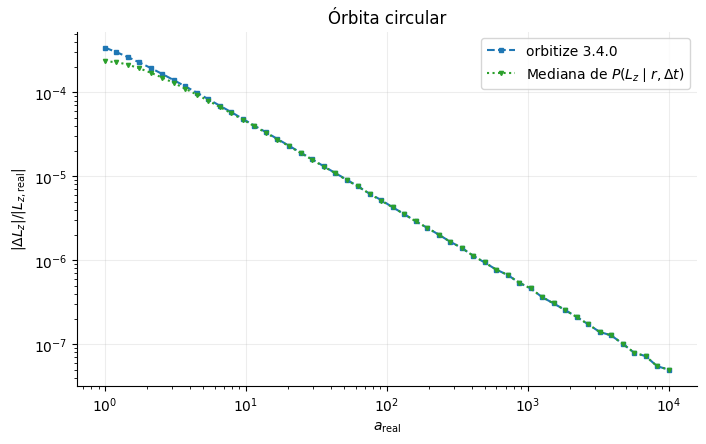

In [7]:
fig, ax = plt.subplots()
plot_Lz_errors(
    ax,
    comparison_circular,
    "a_real",
    ["orbitize", "Position and time posterior"],
    xlog=True,
    title="Órbita circular",
)
ax.set_xlabel(r"$a_{\mathrm{real}}$")
add_in_range_orbit_markers(ax, comparison_circular["a_real"], "a")
plt.show()

In [8]:
comparison_circular.iloc[[0, 12, 24, 37, 49]][
    ["a_real", "orbitize", "Position and time posterior"]
].reset_index(drop=True).rename(
    columns={
        "orbitize": "error relativo, orbitize",
        "Position and time posterior": "error relativo, mediana conjunta",
    }
)

,a_real,"error relativo, orbitize","error relativo, mediana conjunta"
0,1,0.000341,0.000234
1,9.54096,4.82381e-05,4.72669e-05
2,91.0298,5.24057e-06,5.13575e-06
3,"1,048.11",4.63327e-07,4.63327e-07
4,"10,000",5e-08,5e-08


### Interpretación

- La curva verde corresponde al error relativo de la mediana de $P(L_z\mid r,\Delta t)$; la azul usa la estimación puntual del ajuste orbital.
- Ambas curvas se calculan sobre exactamente los mismos puntos perturbados.
- El barrido muestra una realización controlada, no la mediana del error relativo sobre múltiples realizaciones de ruido.
- Los semiejes mayores suministrados para S2 y S301 superan $a=10^4$, por lo que no se marcan en este barrido.
- No se añade una banda al estimador circular en esta actualización rápida: sus muestras por punto no quedaron almacenadas y exigirían recalcular la cuadratura completa.

## 1.2. Prueba 2: órbita elíptica

### 1.2.1. Caso bidimensional

Una cónica kepleriana con el foco en el origen satisface

$$
r(\theta)=\frac{p}{1+e\cos(\theta-\omega)}.
$$

La forma lineal

$$
\frac{1}{r}=A+B\cos\theta+C\sin\theta
$$

permite recuperar

$$
p=\frac{1}{A},\qquad
e=\frac{\sqrt{B^2+C^2}}{A},\qquad
L_z=\sqrt{p}=\frac{1}{\sqrt{A}}
$$

para una órbita vista de frente y $G=M=1$.

> **Incertidumbre mostrada:** las áreas verdes son la transformación al error relativo del intervalo percentil 2.5–97.5 de $L_z$, calculado con 5,000 muestras Monte Carlo. La envolvente contiene por construcción el error de la mediana. Si el intervalo contiene $L_{z,\mathrm{real}}$, su límite inferior es cero y se recorta al borde de la escala logarítmica. Solo se sombrea el estimador posterior; los ajustes puntuales no poseen muestras de incertidumbre.

In [9]:
a_2d = 100.0
ecc_2d = 0.3
aop_2d = 0.7
period_2d = DAYS_PER_ORBIT_1_AU * np.sqrt(a_2d**3 / MASS_SOLAR)
epochs_2d = np.linspace(0, period_2d, NUMBER_OF_POINTS, endpoint=False)
ra_2d, dec_2d, _ = kepler.calc_orbit(
    epochs_2d,
    sma=a_2d,
    ecc=ecc_2d,
    inc=0,
    aop=aop_2d,
    pan=0,
    tau=0.13,
    plx=PARALLAX_MAS,
    mtot=MASS_SOLAR,
    tau_ref_epoch=0,
    use_c=False,
)
x_2d = ra_2d / PARALLAX_MAS
y_2d = dec_2d / PARALLAX_MAS
p_2d, eccentricity_2d, omega_2d = conic_elements(x_2d, y_2d)

pd.DataFrame(
    {
        "cantidad": ["p", "e", "omega", "Lz"],
        "estimación": [
            p_2d,
            eccentricity_2d,
            omega_2d % (2 * np.pi),
            float(estimate_Lz_conic(x_2d, y_2d)),
        ],
        "valor real": [
            a_2d * (1 - ecc_2d**2),
            ecc_2d,
            (np.pi / 2 - aop_2d) % (2 * np.pi),
            np.sqrt(a_2d * (1 - ecc_2d**2)),
        ],
    }
)

,cantidad,estimación,valor real
0,p,91,91
1,e,0.3,0.3
2,omega,0.870796,0.870796
3,Lz,9.53939,9.53939


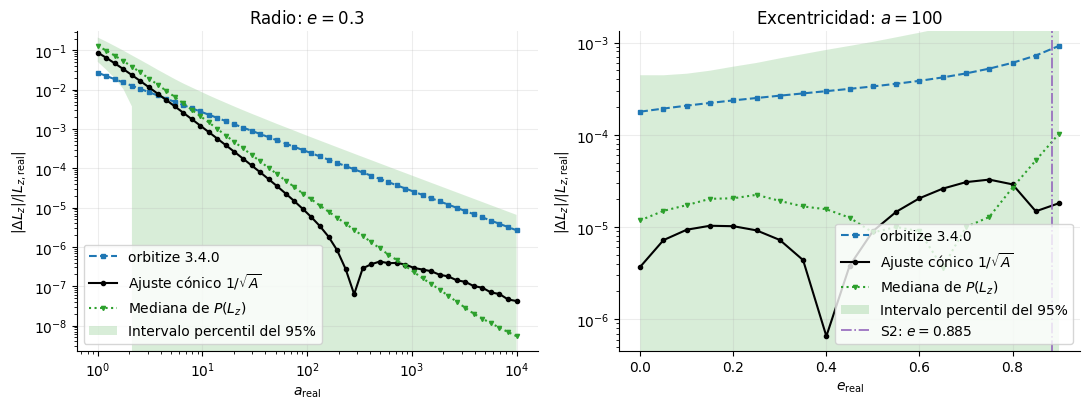

,a_real,"error relativo, ajuste cónico","error relativo, mediana","error relativo, orbitize",barrido,e_real
0,1,0.088297,0.130519,0.0270835,radio,NaN
1,91.0298,9.22926e-06,2.27825e-05,0.00029171,radio,NaN
2,"10,000",4.19314e-08,5.34369e-09,2.65216e-06,radio,NaN
3,NaN,3.7e-06,1.1811e-05,0.000178,excentricidad,0
4,NaN,3.80727e-06,1.26243e-05,0.000314772,excentricidad,0.45
5,NaN,1.81238e-05,0.000103082,0.000920875,excentricidad,0.9


In [10]:
comparison_2d_radius = load_source_result("0e989a17")
comparison_2d_eccentricity = load_source_result("9e04987f")

rng_fixed_2d = np.random.default_rng(SEED + 3)
ra_noise_fixed_2d = rng_fixed_2d.normal(
    0, ASTROMETRIC_ERROR_MAS, NUMBER_OF_POINTS
)
dec_noise_fixed_2d = rng_fixed_2d.normal(
    0, ASTROMETRIC_ERROR_MAS, NUMBER_OF_POINTS
)


def conic_2d_percentile_interval(a_real, eccentricity):
    period = DAYS_PER_ORBIT_1_AU * np.sqrt(a_real**3 / MASS_SOLAR)
    epochs = np.linspace(0, period, NUMBER_OF_POINTS, endpoint=False)
    ra_true, dec_true, _ = kepler.calc_orbit(
        epochs,
        sma=a_real,
        ecc=eccentricity,
        inc=0,
        aop=0.7,
        pan=0,
        tau=0.13,
        plx=PARALLAX_MAS,
        mtot=MASS_SOLAR,
        tau_ref_epoch=0,
        use_c=False,
    )
    x_observed = (ra_true + ra_noise_fixed_2d) / PARALLAX_MAS
    y_observed = (dec_true + dec_noise_fixed_2d) / PARALLAX_MAS
    Lz_samples = get_posterior_Lz_conic(
        x_observed,
        y_observed,
        ASTROMETRIC_ERROR_MAS / PARALLAX_MAS,
        ASTROMETRIC_ERROR_MAS / PARALLAX_MAS,
        number_of_samples=MONTE_CARLO_SAMPLES,
        rng=np.random.default_rng(SEED + 6),
    )
    Lz_real = np.sqrt(a_real * (1 - eccentricity**2))
    return relative_error_percentile_interval(Lz_samples, Lz_real)


band_2d_radius = np.array(
    [
        conic_2d_percentile_interval(a_real, 0.3)
        for a_real in comparison_2d_radius["a_real"]
    ]
)
band_2d_eccentricity = np.array(
    [
        conic_2d_percentile_interval(100.0, eccentricity)
        for eccentricity in comparison_2d_eccentricity["e_real"]
    ]
)
comparison_2d_radius["Conic posterior"] = band_2d_radius[:, 0]
comparison_2d_eccentricity["Conic posterior"] = band_2d_eccentricity[:, 0]
comparison_2d_radius = normalize_Lz_errors(
    comparison_2d_radius,
    np.sqrt(comparison_2d_radius["a_real"] * (1 - 0.3**2)),
    ["Conic fit", "orbitize"],
)
comparison_2d_eccentricity = normalize_Lz_errors(
    comparison_2d_eccentricity,
    np.sqrt(100.0 * (1 - comparison_2d_eccentricity["e_real"] ** 2)),
    ["Conic fit", "orbitize"],
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_Lz_errors(
    axes[0],
    comparison_2d_radius,
    "a_real",
    ["orbitize", "Conic fit", "Conic posterior"],
    xlog=True,
    title=r"Radio: $e=0.3$",
)
shade_percentile_interval(
    axes[0],
    comparison_2d_radius["a_real"],
    band_2d_radius[:, 1],
    band_2d_radius[:, 2],
    "tab:green",
)
axes[0].set_xlabel(r"$a_{\mathrm{real}}$")
add_in_range_orbit_markers(axes[0], comparison_2d_radius["a_real"], "a")

plot_Lz_errors(
    axes[1],
    comparison_2d_eccentricity,
    "e_real",
    ["orbitize", "Conic fit", "Conic posterior"],
    title=r"Excentricidad: $a=100$",
)
shade_percentile_interval(
    axes[1],
    comparison_2d_eccentricity["e_real"],
    band_2d_eccentricity[:, 1],
    band_2d_eccentricity[:, 2],
    "tab:green",
)
axes[1].set_xlabel(r"$e_{\mathrm{real}}$")
add_in_range_orbit_markers(
    axes[1], comparison_2d_eccentricity["e_real"], "e"
)
fig.tight_layout()
plt.show()

pd.concat(
    [
        comparison_2d_radius.iloc[[0, 24, 49]].assign(barrido="radio"),
        comparison_2d_eccentricity.iloc[[0, 9, 18]].assign(barrido="excentricidad"),
    ],
    ignore_index=True,
).rename(
    columns={
        "Conic fit": "error relativo, ajuste cónico",
        "Conic posterior": "error relativo, mediana",
        "orbitize": "error relativo, orbitize",
    }
)

### 1.2.2. Generalización tridimensional

La información de profundidad permite estimar el plano orbital común:

1. La normal $\mathbf{n}$ es el autovector asociado al menor autovalor de $\sum_i \mathbf{r}_i\mathbf{r}_i^T$.
2. Los puntos se proyectan sobre una base ortonormal del plano.
3. En ese plano se aplica el mismo ajuste cónico bidimensional.
4. La componente observable del momento angular es

$$
L_z=\sqrt{p}\,n_z.
$$

La incertidumbre se propaga muestreando conjuntamente $(p,n_z)$; no se supone que ambos parámetros sean independientes.

In [11]:
a_3d = 100.0
ecc_3d = 0.3
inclination_3d = np.deg2rad(40)
aop_3d = 0.7
pan_3d = 1.1
period_3d = DAYS_PER_ORBIT_1_AU * np.sqrt(a_3d**3 / MASS_SOLAR)
epochs_3d = np.linspace(0, period_3d, NUMBER_OF_POINTS, endpoint=False)
x_3d, y_3d, z_3d = kepler_orbit_3d(
    epochs_3d,
    a_3d,
    ecc_3d,
    inclination_3d,
    aop_3d,
    pan_3d,
    tau=0.13,
    mass=MASS_SOLAR,
)
p_3d, nz_3d = conic_elements_3d(x_3d, y_3d, z_3d)
Lz_real_3d = np.sqrt(a_3d * (1 - ecc_3d**2)) * np.cos(inclination_3d)

pd.DataFrame(
    {
        "cantidad": ["p", "n_z", "Lz"],
        "estimación": [
            p_3d,
            nz_3d,
            float(estimate_Lz_conic_3d(x_3d, y_3d, z_3d)),
        ],
        "valor real": [
            a_3d * (1 - ecc_3d**2),
            np.cos(inclination_3d),
            Lz_real_3d,
        ],
    }
)

,cantidad,estimación,valor real
0,p,91,91
1,n_z,0.7660444431189779,0.766044
2,Lz,7.3076,7.3076


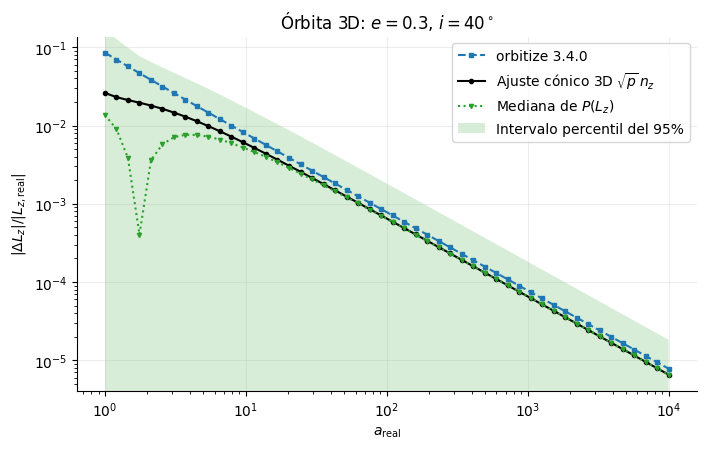

,a_real,"error relativo, ajuste cónico 3D","error relativo, mediana","error relativo, orbitize","corr(p, n_z)"
0,1,0.0261208,0.0136316,0.0856424,-0.078206
1,9.54096,0.00611996,0.0052387,0.00825003,-0.008573
2,91.0298,0.000710828,0.000702241,0.000857125,-0.005252
3,"1,048.11",6.23889e-05,6.2304e-05,7.4351e-05,-0.005042
4,"10,000",6.54114e-06,6.54332e-06,7.8001e-06,-0.005025


In [12]:
comparison_3d_radius = load_source_result("0dd0fb74")

rng_fixed_3d = np.random.default_rng(SEED + 3)
ra_noise_fixed_3d = rng_fixed_3d.normal(
    0, ASTROMETRIC_ERROR_MAS, NUMBER_OF_POINTS
)
dec_noise_fixed_3d = rng_fixed_3d.normal(
    0, ASTROMETRIC_ERROR_MAS, NUMBER_OF_POINTS
)
z_noise_fixed_3d = np.random.default_rng(SEED + 7).normal(
    0, ASTROMETRIC_ERROR_MAS, NUMBER_OF_POINTS
)


def conic_3d_percentile_interval(a_real, eccentricity, inclination, sigma_z=None):
    sigma_z = ASTROMETRIC_ERROR_MAS if sigma_z is None else sigma_z
    period = DAYS_PER_ORBIT_1_AU * np.sqrt(a_real**3 / MASS_SOLAR)
    epochs = np.linspace(0, period, NUMBER_OF_POINTS, endpoint=False)
    x_true, y_true, z_true = kepler_orbit_3d(
        epochs,
        a_real,
        eccentricity,
        inclination,
        0.7,
        1.1,
        tau=0.13,
        mass=MASS_SOLAR,
    )
    x_observed = x_true + dec_noise_fixed_3d / PARALLAX_MAS
    y_observed = y_true + ra_noise_fixed_3d / PARALLAX_MAS
    z_observed = z_true + (
        sigma_z / ASTROMETRIC_ERROR_MAS
    ) * z_noise_fixed_3d / PARALLAX_MAS
    p_samples, nz_samples = get_joint_samples_3d(
        x_observed,
        y_observed,
        z_observed,
        ASTROMETRIC_ERROR_MAS / PARALLAX_MAS,
        ASTROMETRIC_ERROR_MAS / PARALLAX_MAS,
        sigma_z / PARALLAX_MAS,
        number_of_samples=MONTE_CARLO_SAMPLES,
        rng=np.random.default_rng(SEED + 7),
    )
    Lz_samples = np.sqrt(p_samples) * nz_samples
    Lz_real = np.sqrt(a_real * (1 - eccentricity**2)) * np.cos(inclination)
    return relative_error_percentile_interval(Lz_samples, Lz_real)


band_3d_radius = np.array(
    [
        conic_3d_percentile_interval(a_real, 0.3, np.deg2rad(40))
        for a_real in comparison_3d_radius["a_real"]
    ]
)
comparison_3d_radius["Conic 3D posterior"] = band_3d_radius[:, 0]
comparison_3d_radius = normalize_Lz_errors(
    comparison_3d_radius,
    np.sqrt(comparison_3d_radius["a_real"] * (1 - 0.3**2))
    * np.cos(np.deg2rad(40)),
    ["Conic 3D fit", "orbitize"],
)

fig, ax = plt.subplots()
plot_Lz_errors(
    ax,
    comparison_3d_radius,
    "a_real",
    ["orbitize", "Conic 3D fit", "Conic 3D posterior"],
    xlog=True,
    title=r"Órbita 3D: $e=0.3$, $i=40^\circ$",
)
shade_percentile_interval(
    ax,
    comparison_3d_radius["a_real"],
    band_3d_radius[:, 1],
    band_3d_radius[:, 2],
    "tab:green",
)
ax.set_xlabel(r"$a_{\mathrm{real}}$")
add_in_range_orbit_markers(ax, comparison_3d_radius["a_real"], "a")
plt.show()

comparison_3d_radius.iloc[[0, 12, 24, 37, 49]].reset_index(drop=True).rename(
    columns={
        "Conic 3D fit": "error relativo, ajuste cónico 3D",
        "Conic 3D posterior": "error relativo, mediana",
        "orbitize": "error relativo, orbitize",
    }
)

### 1.2.3. Sensibilidad a inclinación y profundidad

La mediana de $P(L_z)$ se compara con el ajuste cónico puntual y con `orbitize` al variar la inclinación y la incertidumbre de profundidad. `orbitize` usa solamente la proyección $(x,y)$; por eso su curva no cambia con $\sigma_z$.

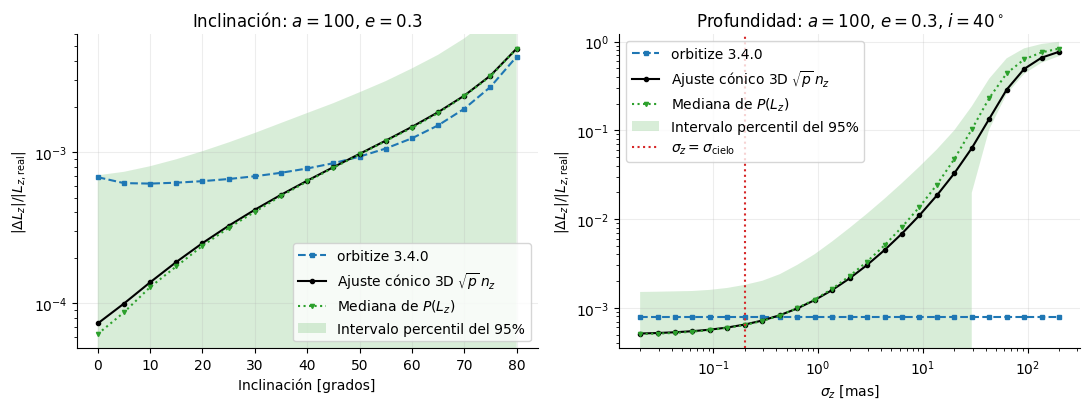

,barrido,puntos,variable mínima,variable máxima
0,inclinación,17,0,80
1,profundidad,25,0.02,200


In [13]:
comparison_3d_inclination = load_source_result("b1acb3de")
comparison_3d_depth = load_source_result("abe4d230")

band_3d_inclination = np.array(
    [
        conic_3d_percentile_interval(100.0, 0.3, np.deg2rad(inclination))
        for inclination in comparison_3d_inclination["inclination_deg"]
    ]
)
band_3d_depth = np.array(
    [
        conic_3d_percentile_interval(
            100.0, 0.3, np.deg2rad(40), sigma_z=sigma_z
        )
        for sigma_z in comparison_3d_depth["sigma_z_mas"]
    ]
)
comparison_3d_inclination["Conic 3D posterior"] = band_3d_inclination[:, 0]
comparison_3d_depth["Conic 3D posterior"] = band_3d_depth[:, 0]
comparison_3d_inclination = normalize_Lz_errors(
    comparison_3d_inclination,
    np.sqrt(100.0 * (1 - 0.3**2))
    * np.abs(np.cos(np.deg2rad(comparison_3d_inclination["inclination_deg"]))),
    ["Conic 3D fit", "orbitize"],
)
comparison_3d_depth = normalize_Lz_errors(
    comparison_3d_depth,
    np.sqrt(100.0 * (1 - 0.3**2)) * np.cos(np.deg2rad(40)),
    ["Conic 3D fit", "orbitize"],
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_Lz_errors(
    axes[0],
    comparison_3d_inclination,
    "inclination_deg",
    ["orbitize", "Conic 3D fit", "Conic 3D posterior"],
    title=r"Inclinación: $a=100$, $e=0.3$",
)
shade_percentile_interval(
    axes[0],
    comparison_3d_inclination["inclination_deg"],
    band_3d_inclination[:, 1],
    band_3d_inclination[:, 2],
    "tab:green",
)
axes[0].set_xlabel("Inclinación [grados]")
axes[0].legend()

plot_Lz_errors(
    axes[1],
    comparison_3d_depth,
    "sigma_z_mas",
    ["orbitize", "Conic 3D fit", "Conic 3D posterior"],
    xlog=True,
    title=r"Profundidad: $a=100$, $e=0.3$, $i=40^\circ$",
)
shade_percentile_interval(
    axes[1],
    comparison_3d_depth["sigma_z_mas"],
    band_3d_depth[:, 1],
    band_3d_depth[:, 2],
    "tab:green",
)
axes[1].axvline(
    ASTROMETRIC_ERROR_MAS,
    color="tab:red",
    linestyle=":",
    label=r"$\sigma_z=\sigma_{\mathrm{cielo}}$",
)
axes[1].set_xlabel(r"$\sigma_z$ [mas]")
axes[1].legend()
fig.tight_layout()
plt.show()

pd.DataFrame(
    {
        "barrido": ["inclinación", "profundidad"],
        "puntos": [len(comparison_3d_inclination), len(comparison_3d_depth)],
        "variable mínima": [
            comparison_3d_inclination["inclination_deg"].min(),
            comparison_3d_depth["sigma_z_mas"].min(),
        ],
        "variable máxima": [
            comparison_3d_inclination["inclination_deg"].max(),
            comparison_3d_depth["sigma_z_mas"].max(),
        ],
    }
)

## 1.3. Prueba 3: geodésicas de Schwarzschild

La actualización del notebook experimental incorpora un ajuste relativista completo mediante `pygro`. Para una órbita ligada, con $p=a(1-e^2)$,

$$
L_z(a,e,i)=\cos i\,\frac{p}{\sqrt{p-3-e^2}}.
$$

Los resultados siguientes usan esta expresión relativista como $L_{z,\mathrm{real}}$. Se presenta primero la mediana del posterior MCMC y después los barridos de radio, excentricidad e inclinación. El MCMC original consumió 35 minutos; aquí se reutilizan sus resultados ejecutados.

> No se recalculan bandas para Schwarzschild: requerirían MCMC o bootstrap, excluidos de esta actualización rápida.

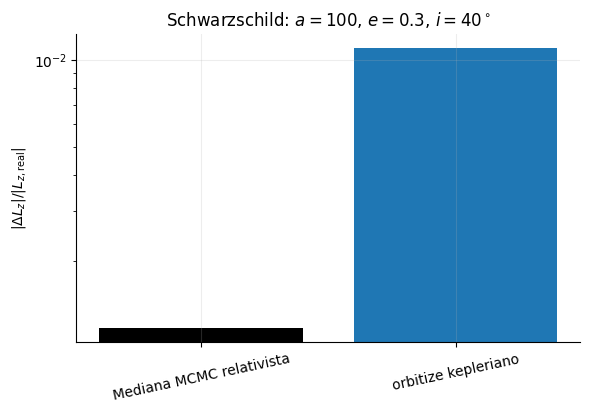

,estimador,error relativo
0,Mediana MCMC relativista,0.00117446
1,orbitize kepleriano,0.0109922


In [14]:
schwarzschild_posterior = load_source_result("64ef741e")
posterior_median = schwarzschild_posterior.loc[
    np.isclose(schwarzschild_posterior["quantile"], 0.5)
].iloc[0]
Lz_real_schwarzschild = float(posterior_median["Lz real"])
schwarzschild_median_comparison = pd.DataFrame(
    {
        "estimador": ["Mediana MCMC relativista", "orbitize kepleriano"],
        "error relativo": [
            abs(float(posterior_median["Lz"]) - Lz_real_schwarzschild)
            / abs(Lz_real_schwarzschild),
            abs(float(posterior_median["orbitize"]) - Lz_real_schwarzschild)
            / abs(Lz_real_schwarzschild),
        ],
    }
)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(
    schwarzschild_median_comparison["estimador"],
    schwarzschild_median_comparison["error relativo"],
    color=["black", "tab:blue"],
)
ax.set_yscale("log")
ax.set_ylabel(r"$|\Delta L_z|/|L_{z,\mathrm{real}}|$")
ax.set_title(r"Schwarzschild: $a=100$, $e=0.3$, $i=40^\circ$")
ax.tick_params(axis="x", rotation=12)
plt.show()

schwarzschild_median_comparison

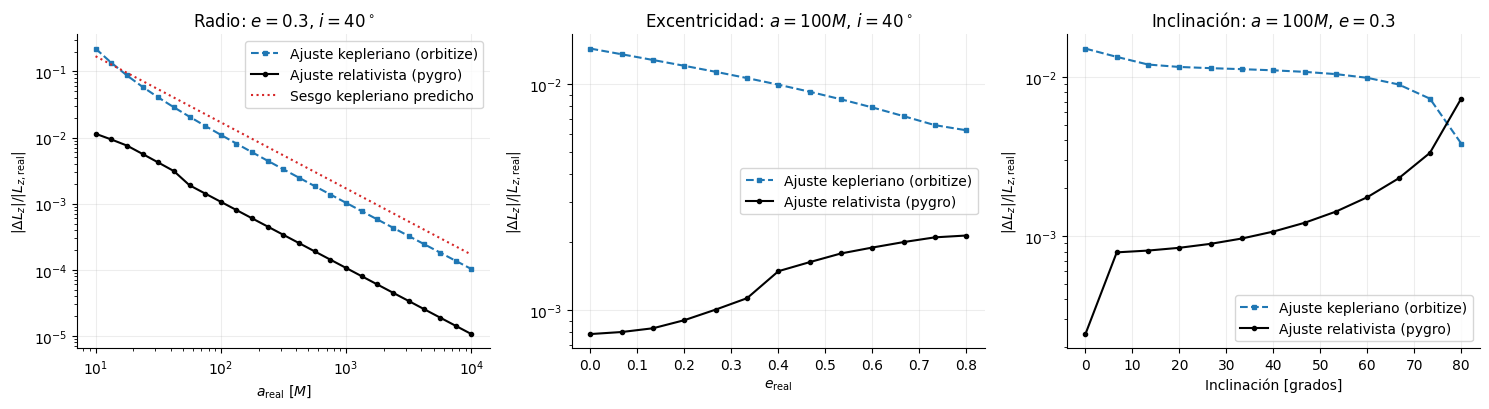

,barrido,puntos,"error relativo mínimo, Schwarzschild","error relativo mínimo, orbitize"
0,radio,25,1.0672e-05,0.000102766
1,excentricidad,13,0.000784777,0.00625407
2,inclinación,13,0.000242437,0.00381343


In [15]:
comparison_schwarzschild_radius = load_source_result("5386ae07")
comparison_schwarzschild_eccentricity = load_source_result("faca91e4")
comparison_schwarzschild_inclination = load_source_result("7a22bc24")


def schwarzschild_Lz_reference(a, e, inclination):
    p = np.asarray(a, dtype=float) * (1 - np.asarray(e, dtype=float) ** 2)
    return np.cos(inclination) * p / np.sqrt(p - 3 - np.asarray(e, dtype=float) ** 2)


comparison_schwarzschild_radius = normalize_Lz_errors(
    comparison_schwarzschild_radius,
    schwarzschild_Lz_reference(
        comparison_schwarzschild_radius["a_real"], 0.3, np.deg2rad(40)
    ),
    ["Schwarzschild (pygro)", "Kepler (orbitize)", "sesgo predicho"],
)
comparison_schwarzschild_eccentricity = normalize_Lz_errors(
    comparison_schwarzschild_eccentricity,
    schwarzschild_Lz_reference(
        100.0,
        comparison_schwarzschild_eccentricity["e_real"],
        np.deg2rad(40),
    ),
    ["Schwarzschild (pygro)", "Kepler (orbitize)"],
)
comparison_schwarzschild_inclination = normalize_Lz_errors(
    comparison_schwarzschild_inclination,
    schwarzschild_Lz_reference(
        100.0,
        0.3,
        np.deg2rad(comparison_schwarzschild_inclination["inclination_deg"]),
    ),
    ["Schwarzschild (pygro)", "Kepler (orbitize)"],
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
plot_Lz_errors(
    axes[0],
    comparison_schwarzschild_radius,
    "a_real",
    ["Kepler (orbitize)", "Schwarzschild (pygro)", "sesgo predicho"],
    xlog=True,
    title=r"Radio: $e=0.3$, $i=40^\circ$",
)
axes[0].set_xlabel(r"$a_{\mathrm{real}}\ [M]$")
add_in_range_orbit_markers(
    axes[0], comparison_schwarzschild_radius["a_real"], "a"
)

plot_Lz_errors(
    axes[1],
    comparison_schwarzschild_eccentricity,
    "e_real",
    ["Kepler (orbitize)", "Schwarzschild (pygro)"],
    title=r"Excentricidad: $a=100M$, $i=40^\circ$",
)
axes[1].set_xlabel(r"$e_{\mathrm{real}}$")
add_in_range_orbit_markers(
    axes[1], comparison_schwarzschild_eccentricity["e_real"], "e"
)

plot_Lz_errors(
    axes[2],
    comparison_schwarzschild_inclination,
    "inclination_deg",
    ["Kepler (orbitize)", "Schwarzschild (pygro)"],
    title=r"Inclinación: $a=100M$, $e=0.3$",
)
axes[2].set_xlabel("Inclinación [grados]")
fig.tight_layout()
plt.show()

pd.DataFrame(
    {
        "barrido": ["radio", "excentricidad", "inclinación"],
        "puntos": [
            len(comparison_schwarzschild_radius),
            len(comparison_schwarzschild_eccentricity),
            len(comparison_schwarzschild_inclination),
        ],
        "error relativo mínimo, Schwarzschild": [
            comparison_schwarzschild_radius["Schwarzschild (pygro)"].min(),
            comparison_schwarzschild_eccentricity["Schwarzschild (pygro)"].min(),
            comparison_schwarzschild_inclination["Schwarzschild (pygro)"].min(),
        ],
        "error relativo mínimo, orbitize": [
            comparison_schwarzschild_radius["Kepler (orbitize)"].min(),
            comparison_schwarzschild_eccentricity["Kepler (orbitize)"].min(),
            comparison_schwarzschild_inclination["Kepler (orbitize)"].min(),
        ],
    }
)

# 2. Conclusiones

1. **Órbita circular:** la mediana del posterior conjunto de posición y tiempo alcanza errores relativos comparables con `orbitize` en el barrido controlado.
2. **Órbita elíptica 2D:** la mediana de $P(L_z)$ mantiene errores relativos pequeños al variar radio y excentricidad.
3. **Órbita elíptica 3D:** la mediana de $P(L_z)$ permite estudiar directamente la sensibilidad relativa a inclinación y profundidad.
4. **Profundidad:** el método 3D pierde ventaja cuando $\sigma_z$ supera la precisión del plano del cielo.
5. **Schwarzschild:** el posterior relativista y sus barridos ya están incorporados; el ajuste kepleriano presenta el sesgo relativo esperado al ignorar la corrección relativista.
6. **Referencias orbitales:** solo $e_{\mathrm{S2}}=0.885$ entra en un intervalo estudiado y se marca en el barrido 2D de excentricidad. Los demás valores suministrados quedan fuera de los rangos correspondientes.
7. **Alcance:** las curvas corresponden a una realización fija de ruido. Falta repetir cada punto para estimar la distribución del error relativo entre realizaciones.

## 2.1. Limitaciones

- Se observa una órbita completa con cadencia uniforme.
- Los barridos reutilizan una sola realización de ruido.
- Las incertidumbres se modelan como gaussianas e independientes.
- La comparación tridimensional entrega profundidad únicamente al estimador cónico.
- El modelo es kepleriano; no incluye todavía correcciones relativistas ni perturbaciones externas.
- Las áreas sombreadas son intervalos percentiles posteriores condicionales a una realización fija de los datos; no son intervalos sobre realizaciones repetidas del experimento.

# Apéndice técnico

## A.1. Comparación de medianas con información temporal

La variante temporal estima $a$ mediante el periodo y $e$ mediante el ajuste cónico. Las tres gráficas comparan los **errores relativos** de su mediana de $L_z$, la mediana geométrica $\sqrt{p}\,n_z$ y `orbitize`.

La variante temporal permanece sin bandas porque necesita un segundo barrido Monte Carlo con filtrado adicional de muestras.

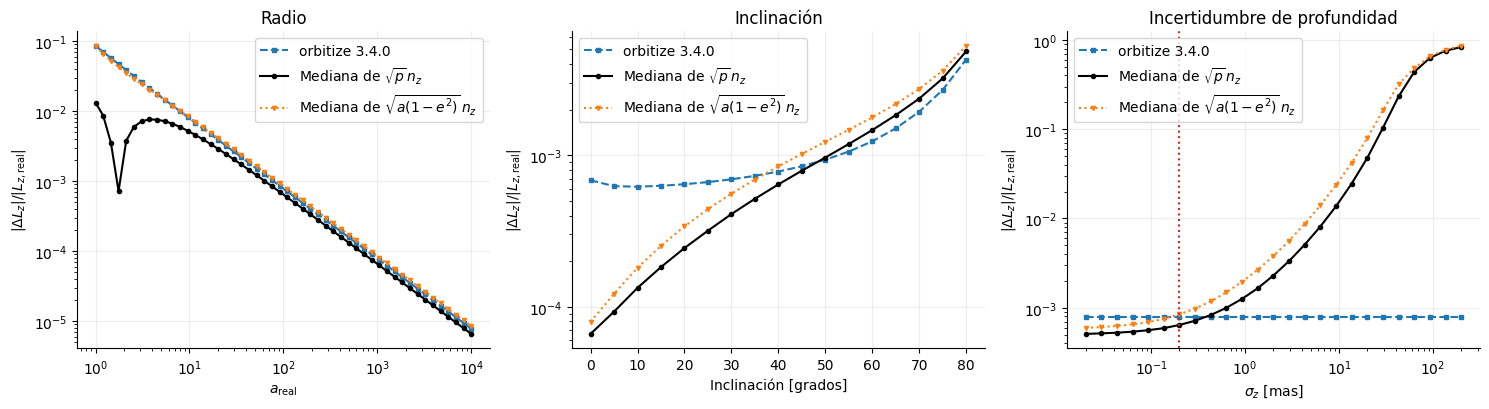

,barrido,puntos
0,radio,50
1,inclinación,17
2,profundidad,25


In [16]:
comparison_time_radius = load_source_result("ecbdd562")
comparison_time_inclination = load_source_result("67d2b81e")
comparison_time_depth = load_source_result("0cc4b8b9")
comparison_time_radius = normalize_Lz_errors(
    comparison_time_radius,
    np.sqrt(comparison_time_radius["a_real"] * (1 - 0.3**2))
    * np.cos(np.deg2rad(40)),
    ["Geometric", "With time", "orbitize"],
)
comparison_time_inclination = normalize_Lz_errors(
    comparison_time_inclination,
    np.sqrt(100.0 * (1 - 0.3**2))
    * np.abs(np.cos(np.deg2rad(comparison_time_inclination["inclination_deg"]))),
    ["Geometric", "With time", "orbitize"],
)
comparison_time_depth = normalize_Lz_errors(
    comparison_time_depth,
    np.sqrt(100.0 * (1 - 0.3**2)) * np.cos(np.deg2rad(40)),
    ["Geometric", "With time", "orbitize"],
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
plot_Lz_errors(
    axes[0],
    comparison_time_radius,
    "a_real",
    ["orbitize", "Geometric", "With time"],
    xlog=True,
    title="Radio",
)
axes[0].set_xlabel(r"$a_{\mathrm{real}}$")
add_in_range_orbit_markers(axes[0], comparison_time_radius["a_real"], "a")

plot_Lz_errors(
    axes[1],
    comparison_time_inclination,
    "inclination_deg",
    ["orbitize", "Geometric", "With time"],
    title="Inclinación",
)
axes[1].set_xlabel("Inclinación [grados]")

plot_Lz_errors(
    axes[2],
    comparison_time_depth,
    "sigma_z_mas",
    ["orbitize", "Geometric", "With time"],
    xlog=True,
    title="Incertidumbre de profundidad",
)
axes[2].axvline(ASTROMETRIC_ERROR_MAS, color="tab:red", linestyle=":")
axes[2].set_xlabel(r"$\sigma_z$ [mas]")
fig.tight_layout()
plt.show()

pd.DataFrame(
    {
        "barrido": ["radio", "inclinación", "profundidad"],
        "puntos": [
            len(comparison_time_radius),
            len(comparison_time_inclination),
            len(comparison_time_depth),
        ],
    }
)

## A.2. Información temporal y degeneración algebraica

Si el periodo determina $a$ y luego se define

$$
e=\sqrt{1-\frac{p}{a}},
$$

entonces

$$
a(1-e^2)=p
$$

y, por tanto,

$$
\sqrt{a(1-e^2)}\,n_z=\sqrt{p}\,n_z.
$$

En esa ruta la información temporal se cancela exactamente en $L_z$. El tiempo solo aporta información nueva si $a$ y $e$ se estiman mediante restricciones independientes.

In [17]:
p_demo = np.geomspace(1, 100, 1_000)
nz_demo = np.linspace(0.2, 1.0, len(p_demo))
a_demo = 1.5 * p_demo
e_demo = np.sqrt(1 - p_demo / a_demo)
Lz_from_a_e = np.sqrt(a_demo * (1 - e_demo**2)) * nz_demo
Lz_from_p = np.sqrt(p_demo) * nz_demo

pd.DataFrame(
    {
        "identidad comprobada": [
            r"sqrt(a(1-e^2)) n_z = sqrt(p) n_z",
        ],
        "máxima diferencia relativa": [
            float(
                np.max(np.abs(Lz_from_a_e - Lz_from_p) / np.abs(Lz_from_p))
            ),
        ],
    }
)

,identidad comprobada,máxima diferencia relativa
0,sqrt(a(1-e^2)) n_z = sqrt(p) n_z,3.22879e-16


## A.3. Experimentos conservados en el notebook de pruebas

El notebook experimental mantiene ramas útiles para investigación, pero demasiado extensas o preliminares para la narrativa principal.

In [18]:
pd.DataFrame(
    {
        "rama": [
            "Errores anisotrópicos y distribuciones arbitrarias",
            "Transformación RA/DEC",
            "Estimador basado únicamente en tiempos",
            "Barridos completos de radio, inclinación y profundidad",
            "Ajuste relativista de Schwarzschild",
        ],
        "estado": [
            "Exploratoria",
            "Aproximación de ángulo pequeño",
            "Limitado a pares y cadencia controlada",
            "Disponibles en notebook fuente y archivo NPZ",
            "Completada en el notebook fuente; resumida en la sección 1.3",
        ],
        "ubicación": [
            "notebooks/011..., secciones 2D/3D generales",
            "notebooks/011..., sección RA/DEC",
            "notebooks/011..., sección tiempo",
            "notebooks/011... y data/011.../inclination_map.npz",
            "notebooks/011..., sección Schwarzschild",
        ],
    }
)

,rama,estado,ubicación
0,Errores anisotrópicos y distribuciones arbitra...,Exploratoria,"notebooks/011..., secciones 2D/3D generales"
1,Transformación RA/DEC,Aproximación de ángulo pequeño,"notebooks/011..., sección RA/DEC"
2,Estimador basado únicamente en tiempos,Limitado a pares y cadencia controlada,"notebooks/011..., sección tiempo"
3,"Barridos completos de radio, inclinación y pro...",Disponibles en notebook fuente y archivo NPZ,notebooks/011... y data/011.../inclination_map...
4,Ajuste relativista de Schwarzschild,Completada en el notebook fuente; resumida en ...,"notebooks/011..., sección Schwarzschild"
